# VGG 16 MODEL(CBIS-DDSM(REMOVE BACKGROUND))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import drive
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

In [ ]:
vgg_base.trainable = False

In [ ]:
x = GlobalAveragePooling2D()(vgg_base.output)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

predictions = Dense(1, activation='sigmoid')(x)

**DEFINE DATASET(Reove background CBIS-DDSM dataset
) PATH**

In [ ]:
base_dataset = "/content/drive/MyDrive/DDSMset_Cleaned"

In [ ]:
img_size = (256, 256)
batch_size = 12

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    horizontal_flip=False,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    base_dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1246 images belonging to 2 classes.
Found 310 images belonging to 2 classes.


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0080906148867315), 1: np.float64(0.9920382165605095)}


In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
vgg_model = Model(inputs=vgg_base.input, outputs=predictions)

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', 'auc', 'precision', 'recall']
)

In [ ]:
vgg_history = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 473s 5s/step - accuracy: 0.5449 - auc: 0.5532 - loss: 0.8440 - precision: 0.5496 - recall: 0.5382 - val_accuracy: 0.5710 - val_auc: 0.6252 - val_loss: 0.6881 - val_precision: 0.6075 - val_recall: 0.4167 - learning_rate: 0.0010
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5827 - auc: 0.6182 - loss: 0.7274 - precision: 0.5879 - recall: 0.5748 - val_accuracy: 0.5839 - val_auc: 0.6391 - val_loss: 0.6854 - val_precision: 0.5780 - val_recall: 0.6410 - learning_rate: 0.0010
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.5803 - auc: 0.6224 - loss: 0.7131 - precision: 0.5891 - recall: 0.5525 - val_accuracy: 0.5548 - val_auc: 0.6182 - val_loss: 0.7471 - val_precision: 0.6000 - val_recall: 0.3462 - learning_rate: 0.0010
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6164 - auc: 0.6625 - loss: 0.6812 - precision: 0.6126 - recall: 0.6497 - val_accuracy: 0.5871 - val_auc: 0.6216 - val_loss: 0.6835 -

In [ ]:
vgg_model.save("/content/drive/MyDrive/VGG16phase1_DDSM_cleaned.h5")
print("Model saved successfully")

Model saved successfully


In [ ]:
for layer in vgg_base.layers[-4:]:
    layer.trainable = True

In [ ]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', 'auc', 'precision', 'recall']
)

In [ ]:
fine_tune_history = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.6477 - auc: 0.7070 - loss: 0.6321 - precision: 0.6649 - recall: 0.6067 - val_accuracy: 0.5903 - val_auc: 0.6605 - val_loss: 0.6766 - val_precision: 0.6629 - val_recall: 0.3782 - learning_rate: 1.0000e-05
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6685 - auc: 0.7183 - loss: 0.6261 - precision: 0.6807 - recall: 0.6449 - val_accuracy: 0.6129 - val_auc: 0.6568 - val_loss: 0.6581 - val_precision: 0.6429 - val_recall: 0.5192 - learning_rate: 1.0000e-05
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6847 - auc: 0.7659 - loss: 0.5692 - precision: 0.6946 - recall: 0.6594
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
104/104 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.6942 - auc: 0.7691 - loss: 0.5712 - precision: 0.7076 - recall: 0.6704 - val_accuracy: 0.6097 - val_auc: 0.6466 - val_loss: 0.6674 - val_precision: 0.6036 - val_recall: 0.6538 - learning_rat

In [ ]:
vgg_model.save("/content/drive/MyDrive/VGG16phase2_DDSM_cleaned.h5")
print("Model saved successfully")

Model saved successfully


In [ ]:
# predictions
pred_probs = vgg_model.predict(val_generator)
pred_labels = (pred_probs > 0.5).astype(int)

# true labels
true_labels = val_generator.classes

print(classification_report(true_labels, pred_labels))
print(confusion_matrix(true_labels, pred_labels))

26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 908ms/step
              precision    recall  f1-score   support

           0       0.61      0.58      0.59       154
           1       0.60      0.63      0.62       156

    accuracy                           0.61       310
   macro avg       0.61      0.61      0.61       310
weighted avg       0.61      0.61      0.61       310

[[89 65]
 [57 99]]


In [ ]:
pred_labels = (pred_probs > 0.4).astype(int)

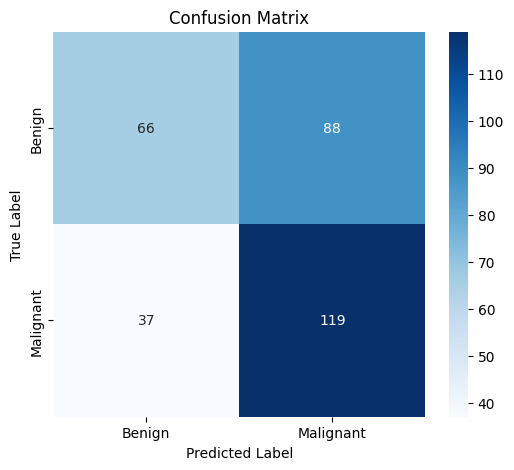

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

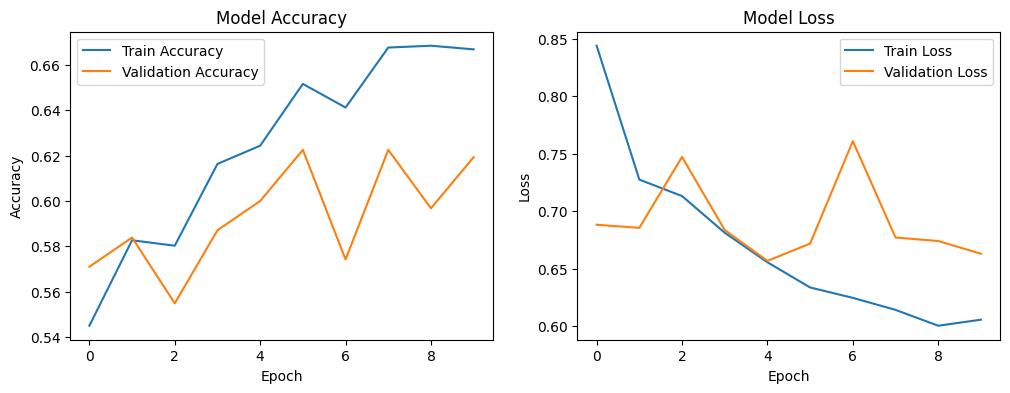

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

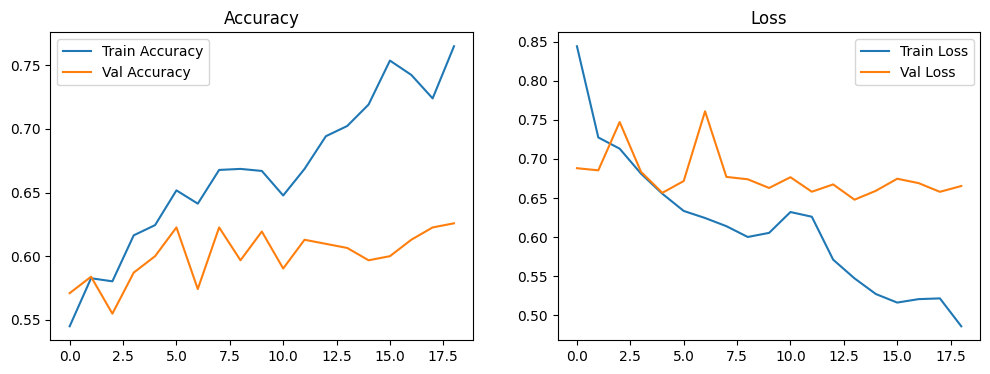

In [ ]:
acc = vgg_history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = vgg_history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = vgg_history.history['loss'] + fine_tune_history.history['loss']
val_loss = vgg_history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(acc,label='Train Accuracy')
plt.plot(val_acc,label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label='Train Loss')
plt.plot(val_loss,label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

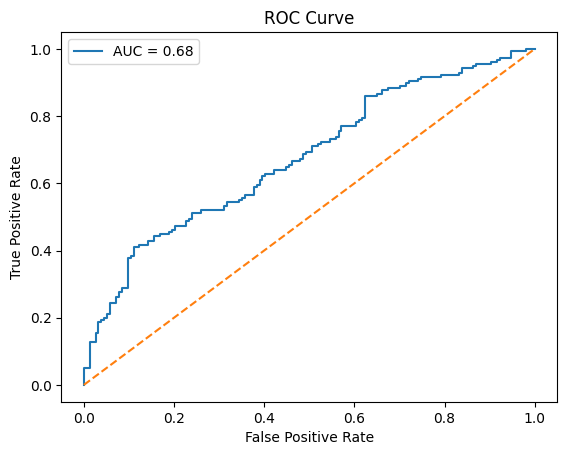

In [ ]:
fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
vgg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,44

 Total params: 29,319,109 (111.84 MB)

 Trainable params: 7,227,777 (27.57 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

 Optimizer params: 14,455,556 (55.14 MB)

In [ ]:
K.clear_session()